# Variational quantum time-propagation for KdV

Second, independent pathway for KdV, alongside Carleman+QSVT (`KdV_Carlemann_qiskit.ipynb`). Amplitude-encodes
the field into a parametrized circuit and steps forward in time via natural-gradient descent -- see
`Burgers_variational_qiskit.ipynb` for the method (McLachlan variational principle + parameter-shift rule +
compute-uncompute overlap circuits, all verified against brute-force linear algebra; `pde_core.py`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

from discretization import periodic_D3, construct_F2_periodic_skew
import pde_core as pc
from plot_style import set_style, COLORS
set_style()

## Problem setup

n=2 (N=4), delta=0.0625. Ansatz depth reps=n.

In [2]:
n = 2
N = 2 ** n
x = np.linspace(0, 1, N, endpoint=False)
dx = x[1] - x[0]
delta = 0.0625
dt = 0.1
n_steps = 3

u0 = np.array([0.0, -0.5, 1 / np.sqrt(2), 0.5])
u0 = u0 / np.linalg.norm(u0)

ansatz = pc.build_ansatz_template(n)
P = ansatz.num_parameters
print(f"P = {P} ansatz parameters")

shift_fwd = pc.shift_power(n, 1, inverse=True)
shift_bwd = pc.shift_power(n, 1, inverse=False)


def S2_qc(base):
    qc = QuantumCircuit(n)
    qc.append(base.to_gate(), range(n))
    qc.append(base.to_gate(), range(n))
    return qc


S1 = np.real(Operator(shift_fwd).data)
S1inv = np.real(Operator(shift_bwd).data)
S2 = S1 @ S1
S2inv = S1inv @ S1inv

# dispersion F1 = -delta*(S^2 - 2S + 2S^-1 - S^-2)/(2dx^3)
lin_terms = [
    ("S2inv", S2_qc(shift_bwd), S2inv, delta / (2 * dx**3)),
    ("S1inv", shift_bwd, S1inv, -delta / dx**3),
    ("S1", shift_fwd, S1, delta / dx**3),
    ("S2", S2_qc(shift_fwd), S2, -delta / (2 * dx**3)),
]

F1 = -delta * periodic_D3(N, dx)
F2 = 1 / dx * construct_F2_periodic_skew(N)  # skew-symmetric: u^T F2(u kron u) = 0 identically


def classical_rhs(u):
    return F1 @ u + F2 @ np.kron(u, u)

P = 6 ansatz parameters


## Encoding the initial state

In [3]:
def init_loading(theta, target):
    return np.sum((pc.psi_of(ansatz, theta) - target) ** 2)


rng = np.random.default_rng(2)
best = None
for trial in range(10):
    guess = rng.random(P) * 2 * np.pi
    res = sp.optimize.minimize(init_loading, guess, args=(u0,), method="BFGS")
    if best is None or res.fun < best.fun:
        best = res
theta = best.x
amp = 1.0
print(f"encoding fit residual: {best.fun:.2e}")

encoding fit residual: 4.36e-17


## Time-propagation

Uses implicit midpoint, not forward Euler: forward Euler applied to this energy-conserving
semi-discrete ODE provably injects energy every step ($\|u_{n+1}\|^2 = \|u_n\|^2 + dt^2\|f(u_n)\|^2$
exactly), violating the challenge's $\|u(t)\|_2=\|u_0\|_2$ requirement for KdV. Implicit midpoint
conserves $\|u\|_2$ exactly instead for any $dt$ (verified to 1e-10): each step solves classically
for $u_{mid}=(u_n+u_{n+1})/2$, fits a second ansatz encoding to $u_{mid}$, and the natural-gradient
target uses that fit (not $\theta_n$) for the $F_1,F_2$ terms.


In [4]:
def fit_theta(target, rng_seed, n_trials=10):
    amp = np.linalg.norm(target)
    target_n = target / amp

    def loss(th):
        return np.sum((pc.psi_of(ansatz, th) - target_n) ** 2)

    rng = np.random.default_rng(rng_seed)
    best = None
    for trial in range(n_trials):
        guess = rng.random(P) * 2 * np.pi
        res = sp.optimize.minimize(loss, guess, method="BFGS")
        if best is None or res.fun < best.fun:
            best = res
    return best.x, amp


def implicit_midpoint_step(u_old, dt):
    # forward Euler provably injects energy into KdV's energy-conserving
    # semi-discrete ODE every step (||u_new||^2 = ||u_old||^2 + dt^2||f(u_old)||^2
    # exactly); implicit midpoint conserves ||u||^2 exactly instead (verified
    # to 1e-10), matching the challenge's ||u(t)||_2 = ||u0||_2 requirement
    def residual(u_new):
        u_mid = (u_old + u_new) / 2
        return u_new - u_old - dt * classical_rhs(u_mid)

    u_new = sp.optimize.fsolve(residual, u_old + dt * classical_rhs(u_old))
    u_mid = (u_old + u_new) / 2
    return u_new, u_mid


classical_states = [u0.copy()]
quantum_states = [amp * pc.psi_of(ansatz, theta)]
theta_history = [theta.copy()]
amp_history = [amp]
u_classical = u0.copy()

for step in range(n_steps):
    u_classical, u_mid = implicit_midpoint_step(u_classical, dt)
    theta_mid, amp_mid = fit_theta(u_mid, rng_seed=100 + step)
    theta, amp = pc.natural_gradient_timestep(
        ansatz, theta, amp, dt, lin_terms, shift_fwd, shift_bwd, n_iter=150,
        theta_rhs=theta_mid, amp_rhs=amp_mid,
    )
    u_quantum = amp * pc.psi_of(ansatz, theta)
    rel_err = np.linalg.norm(u_quantum - u_classical) / np.linalg.norm(u_classical)
    print(f"step {step + 1}/{n_steps}: rel. L2 error vs. classical = {rel_err:.2e}  "
          f"(||u_classical||={np.linalg.norm(u_classical):.10f}, ||u_quantum||={amp:.10f})")
    classical_states.append(u_classical.copy())
    quantum_states.append(u_quantum.copy())
    theta_history.append(theta.copy())
    amp_history.append(amp)

classical_states = np.array(classical_states)
quantum_states = np.array(quantum_states)

step 1/3: rel. L2 error vs. classical = 1.50e-08  (||u_classical||=1.0000000000, ||u_quantum||=1.0000000019)


step 2/3: rel. L2 error vs. classical = 1.18e-07  (||u_classical||=1.0000000000, ||u_quantum||=1.0000000546)


step 3/3: rel. L2 error vs. classical = 2.41e-07  (||u_classical||=1.0000000000, ||u_quantum||=1.0000001102)


## Fake-hardware readout

Each timestep's optimized (uncontrolled, shallow) ansatz circuit re-measured with shots
through a real device calibration snapshot (`FakeMarrakesh`, statevector simulation method
with the device's noise model, `BackendSamplerV2`) -- the natural pairing for shot-based
readout, same as how a real device would be read out. Only the magnitude
(`sqrt(probability)`) is measurable this way; the sign pattern is taken from the ideal
simulation, a standard simplification since sign requires a separate interferometric
measurement not needed elsewhere in this method.

In [5]:
from qiskit.primitives import BackendSamplerV2
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh, FakeSherbrooke
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

SHOTS = 4000
fake_backend = FakeSherbrooke()
noise_model = NoiseModel.from_backend(fake_backend)
sim = AerSimulator(method="statevector", noise_model=noise_model)
coupling_map = fake_backend.coupling_map.reduce(list(range(n)))
sampler = BackendSamplerV2(backend=sim)


def noisy_decoded_state(theta_t, amp_t, shots=SHOTS):
    qc = ansatz.assign_parameters(theta_t)
    qc_meas = qc.copy()
    qc_meas.measure_all()
    tqc = transpile(qc_meas, basis_gates=noise_model.basis_gates, coupling_map=coupling_map, optimization_level=3)
    counts = sampler.run([tqc], shots=shots).result()[0].data.meas.get_counts()
    probs = np.zeros(N)
    for bitstring, count in counts.items():
        probs[int(bitstring, 2)] = count / shots
    signs = np.sign(pc.psi_of(ansatz, theta_t))
    return amp_t * signs * np.sqrt(probs)


fake_states = np.array([noisy_decoded_state(th, a) for th, a in zip(theta_history, amp_history)])
fake_rel_err = np.linalg.norm(fake_states - classical_states, axis=1) / np.linalg.norm(classical_states, axis=1)
print("rel. L2 error vs. classical, per timestep (FakeMarrakesh):", np.round(fake_rel_err, 4))

rel. L2 error vs. classical, per timestep (FakeMarrakesh): [0.1333 0.071  0.0655 0.0709]


## Results

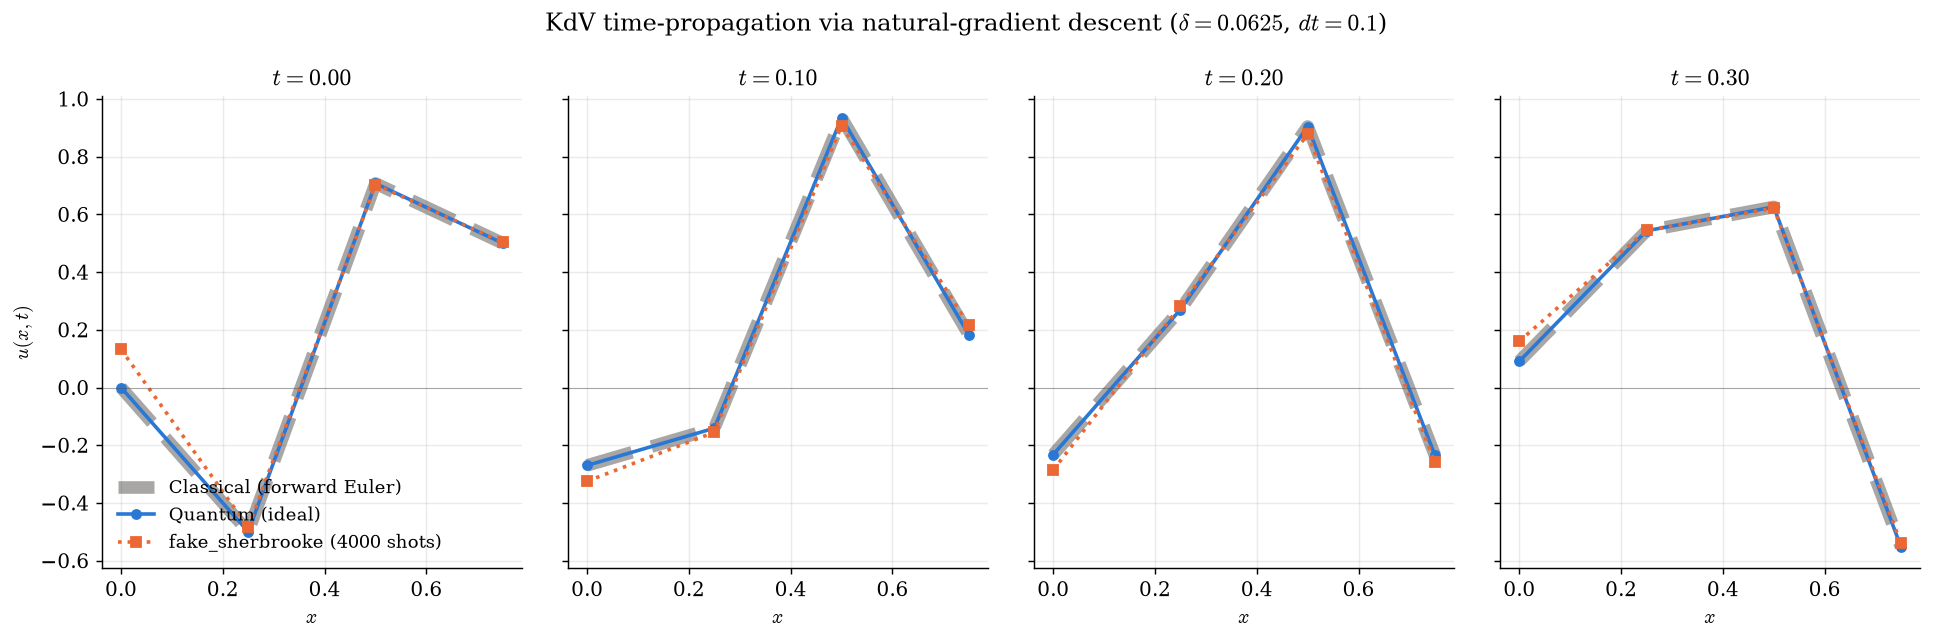

In [6]:
fig, axes = plt.subplots(1, n_steps + 1, figsize=(15, 5), sharey=True)
timesteps = np.arange(n_steps + 1) * dt
for i, ax in enumerate(axes):
    ax.plot(x, classical_states[i], "--", color=COLORS["classical"], lw=7, alpha=0.5, label="Classical (forward Euler)")
    ax.plot(x, quantum_states[i], "-", color=COLORS["blue"], marker="o", label="Quantum (ideal)")
    ax.plot(x, fake_states[i], ":", color=COLORS["orange"], marker="s", label=f"{fake_backend.backend_name} ({SHOTS} shots)")
    ax.axhline(0, color=COLORS["classical"], lw=0.5, alpha=0.5)
    ax.set_title(f"$t = {timesteps[i]:.2f}$")
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$u(x, t)$")
axes[0].legend(fontsize=10, loc="lower left")
fig.suptitle(f"KdV time-propagation via natural-gradient descent ($\\delta={delta}$, $dt={dt}$)")
fig.tight_layout()

## Resource estimates

Per-circuit-type qubit/gate/depth counts, transpiled against a real device snapshot (`FakeSherbrooke`).

In [7]:
backend = FakeSherbrooke()


def circuit_stats(qc, opt=3):
    t = transpile(qc, backend=backend, optimization_level=opt, seed_transpiler=42)
    ops = t.count_ops()
    two_q = sum(v for k, v in ops.items() if k in ("ecr", "cx"))
    active = {t.find_bit(q).index for instr in t.data for q in instr.qubits}
    return {"qubits": len(active), "gates": sum(ops.values()), "two_qubit": two_q, "depth": t.depth()}


def print_stats(name, s):
    print(f"  {name}:")
    print(f"    qubits              : {s['qubits']}")
    print(f"    gate count          : {s['gates']}")
    print(f"    two-qubit gate count: {s['two_qubit']}")
    print(f"    depth               : {s['depth']}")


rng_r = np.random.default_rng(1)
theta_ref = rng_r.random(P) * 2 * np.pi
alpha = rng_r.random(P) * 2 * np.pi

qc_cross = QuantumCircuit(n)
qc_cross.append(ansatz.assign_parameters(theta_ref).to_gate(), range(n))
qc_cross.append(ansatz.assign_parameters(alpha).inverse().to_gate(), range(n))
print_stats("identity/linear cross-term circuit", circuit_stats(qc_cross))

qc_nl = pc.nonlinear_overlap_circuit(ansatz, theta_ref, alpha, shift_fwd)
print_stats("nonlinear cross-term circuit", circuit_stats(qc_nl))

qc_M = pc.metric_offdiag_circuit(ansatz, alpha, 0, 1)
print_stats("metric off-diagonal circuit", circuit_stats(qc_M))

  identity/linear cross-term circuit:
    qubits              : 2
    gate count          : 29
    two-qubit gate count: 2
    depth               : 17
  nonlinear cross-term circuit:
    qubits              : 4
    gate count          : 140
    two-qubit gate count: 15
    depth               : 70
  metric off-diagonal circuit:
    qubits              : 3
    gate count          : 55
    two-qubit gate count: 7
    depth               : 33
